# Sample code with KID

In [1]:
from torchmetrics.image.kid import KernelInceptionDistance
import torch
from torch import randint
kid = KernelInceptionDistance(subset_size=50)
# generate two slightly overlapping image intensity distributions
imgs_dist1 = randint(0, 200, (100, 3, 299, 299), dtype=torch.uint8)
imgs_dist2 = randint(100, 255, (100, 3, 299, 299), dtype=torch.uint8)
kid.update(imgs_dist1, real=True)
kid.update(imgs_dist2, real=False)
kid.compute()

c:\Users\nouran\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\nouran/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:40<00:00, 2.36MB/s]


(tensor(0.0327), tensor(0.0024))

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time, math, os

os.makedirs('results/comparison', exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
transform = transforms.Compose([transforms.ToTensor()])
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
target_classes = {0: 0, 5: 1, 8: 2}
CLASSES = ('plane', 'dog', 'ship')

indices = [i for i, t in enumerate(test_dataset.targets) if t in target_classes][:2000]
test_dataset.data = test_dataset.data[indices]
test_dataset.targets = [target_classes[test_dataset.targets[i]] for i in indices]
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=0)


Files already downloaded and verified


In [ ]:
from dataclasses import dataclass

@dataclass
class VAEConfig:
    in_channels: int = 3
    latent_dim: int = 128
    base_channels: int = 32
    lr: float = 1e-3
    batch_size: int = 128
    epochs: int = 100
    beta: float = 1.0
    seed: int = 42

class ConvVAE(nn.Module):
    def __init__(self, cfg: VAEConfig):
        super().__init__()
        C = cfg.base_channels
        self.encoder = nn.Sequential(
            nn.Conv2d(cfg.in_channels, C,   4, 2, 1), nn.BatchNorm2d(C),   nn.LeakyReLU(0.2),
            nn.Conv2d(C,   C*2, 4, 2, 1), nn.BatchNorm2d(C*2), nn.LeakyReLU(0.2),
            nn.Conv2d(C*2, C*4, 4, 2, 1), nn.BatchNorm2d(C*4), nn.LeakyReLU(0.2),
            nn.Conv2d(C*4, C*8, 4, 2, 1), nn.BatchNorm2d(C*8), nn.LeakyReLU(0.2),
            nn.Flatten(),
        )
        flat_dim = C * 8 * 2 * 2
        self.fc_mu     = nn.Linear(flat_dim, cfg.latent_dim)
        self.fc_logvar = nn.Linear(flat_dim, cfg.latent_dim)
        self.decoder_input = nn.Linear(cfg.latent_dim, flat_dim)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(C*8, C*4, 4, 2, 1), nn.BatchNorm2d(C*4), nn.ReLU(),
            nn.ConvTranspose2d(C*4, C*2, 4, 2, 1), nn.BatchNorm2d(C*2), nn.ReLU(),
            nn.ConvTranspose2d(C*2, C,   4, 2, 1), nn.BatchNorm2d(C),   nn.ReLU(),
            nn.ConvTranspose2d(C, cfg.in_channels, 4, 2, 1), nn.Sigmoid(),
        )
        self.cfg = cfg

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)

    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, self.cfg.base_channels * 8, 2, 2)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar



In [5]:
@dataclass
class DDPMConfig:
    timesteps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 0.02
    in_channels: int = 3
    base_channels: int = 32
    time_emb_dim: int = 128
    lr: float = 1e-4
    batch_size: int = 64
    epochs: int = 100
    seed: int = 42

class NoiseSchedule:
    def __init__(self, cfg):
        self.T = cfg.timesteps
        self.betas = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.timesteps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        self.sqrt_alphas = torch.sqrt(self.alphas)

    def add_noise(self, x_0, t, noise):
        a = self.sqrt_alphas_cumprod[t].view(-1,1,1,1).to(x_0.device)
        b = self.sqrt_one_minus_alphas_cumprod[t].view(-1,1,1,1).to(x_0.device)
        return a * x_0 + b * noise

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([args.sin(), args.cos()], dim=-1)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.act = nn.SiLU()
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_proj(self.act(t_emb)).unsqueeze(-1).unsqueeze(-1)
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.residual(x)

class SimpleUNet(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        C = cfg.base_channels; T = cfg.time_emb_dim
        self.time_embed = nn.Sequential(SinusoidalTimeEmbedding(T), nn.Linear(T, T), nn.SiLU())
        self.down1 = ConvBlock(cfg.in_channels, C, T)
        self.down2 = ConvBlock(C, C*2, T)
        self.pool = nn.MaxPool2d(2)
        self.bot = ConvBlock(C*2, C*2, T)
        self.up_conv2 = nn.ConvTranspose2d(C*2, C*2, 2, stride=2)
        self.up2 = ConvBlock(C*4, C, T)
        self.up_conv1 = nn.ConvTranspose2d(C, C, 2, stride=2)
        self.up1 = ConvBlock(C*2, C, T)
        self.out = nn.Conv2d(C, cfg.in_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_embed(t)
        d1 = self.down1(x, t_emb)
        d2 = self.down2(self.pool(d1), t_emb)
        b = self.bot(self.pool(d2), t_emb)
        u2 = self.up2(torch.cat([self.up_conv2(b), d2], dim=1), t_emb)
        u1 = self.up1(torch.cat([self.up_conv1(u2), d1], dim=1), t_emb)
        return self.out(u1)

# 

In [ ]:
vae_cfg = VAEConfig(beta=1.0)
vae_model = ConvVAE(vae_cfg).to(device)
# A method from Model class in PyTorch
vae_model.load_state_dict(torch.load('results/vae/model_beta1.0.pt', map_location=device))
vae_model.eval()

ddpm_cfg = DDPMConfig()
ddpm_model = SimpleUNet(ddpm_cfg).to(device)
ddpm_model.load_state_dict(torch.load('results/ddpm/model.pt', map_location=device))
ddpm_model.eval()

schedule = NoiseSchedule(ddpm_cfg)
print("Both models loaded!")

Both models loaded!


Generating DDPM samples (this takes a few minutes on CPU)...


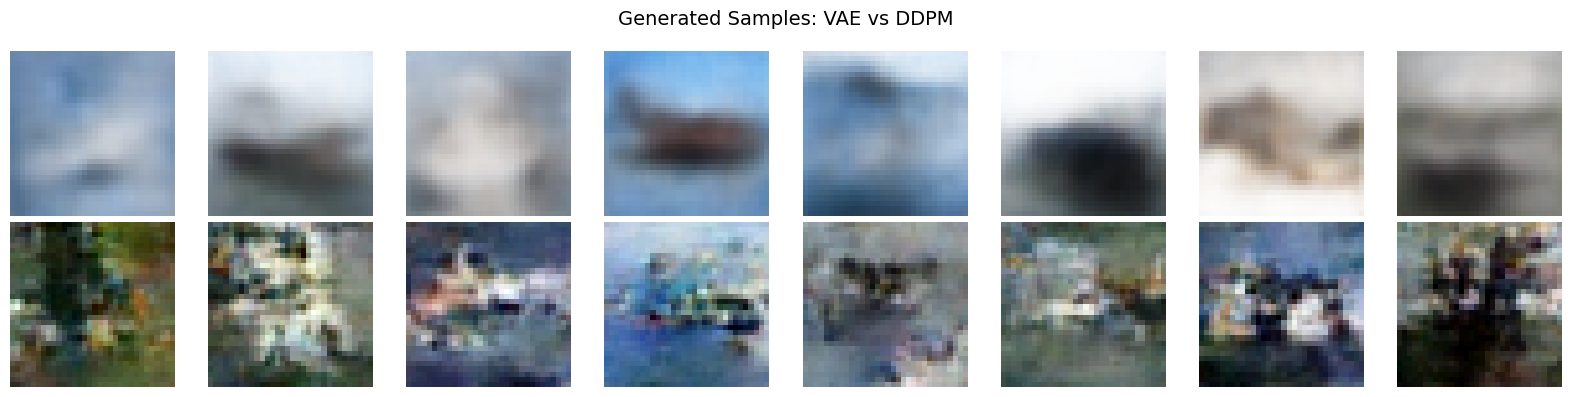

In [7]:

# VAE: sample z ~ N(0,1), decode
with torch.no_grad():
    z = torch.randn(8, vae_cfg.latent_dim).to(device)
    vae_samples = vae_model.decode(z).cpu()

# DDPM: start from noise, denoise 1000 steps
@torch.no_grad()
def ddpm_sample(model, n=8):
    model.eval()
    x = torch.randn(n, 3, 32, 32).to(device)
    for t_val in range(ddpm_cfg.timesteps - 1, -1, -1):
        t = torch.full((n,), t_val, device=device, dtype=torch.long)
        noise_pred = model(x, t)
        alpha_t = schedule.alphas[t_val]
        beta_t = schedule.betas[t_val]
        coef = beta_t / schedule.sqrt_one_minus_alphas_cumprod[t_val]
        x = (1 / torch.sqrt(alpha_t)) * (x - coef * noise_pred)
        if t_val > 0:
            x = x + torch.sqrt(beta_t) * torch.randn_like(x)
    return x.clamp(0, 1).cpu()

print("Generating DDPM samples (this takes a few minutes on CPU)...")
ddpm_samples = ddpm_sample(ddpm_model, n=8)

# Plot side by side
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0,i].imshow(vae_samples[i].clamp(0,1).permute(1,2,0)); axes[0,i].axis('off')
    axes[1,i].imshow(ddpm_samples[i].permute(1,2,0));            axes[1,i].axis('off')
axes[0,0].set_ylabel('VAE', fontsize=12, rotation=0, labelpad=35)
axes[1,0].set_ylabel('DDPM', fontsize=12, rotation=0, labelpad=35)
plt.suptitle('Generated Samples: VAE vs DDPM', fontsize=14)
plt.tight_layout(); plt.savefig('results/comparison/generated_samples.png', dpi=150); plt.show()


In [ ]:
# KID (generation quality metric — works with ~100 samples)
from torchmetrics.image.kid import KernelInceptionDistance

N_SAMPLES = 100  # enough for KID, feasible on CPU

# Collect real images (uint8 0-255, shape: N×3×299×299 — torchmetrics handles resizing)
real_imgs = []
for imgs, _ in test_loader:
    real_imgs.append(imgs)
    if sum(r.shape[0] for r in real_imgs) >= N_SAMPLES:
        break
real_imgs = torch.cat(real_imgs)[:N_SAMPLES]
# KID expects uint8 [0, 255]
real_uint8 = (real_imgs * 255).to(torch.uint8)

# Generate VAE samples (instant)
print(f"Generating {N_SAMPLES} VAE samples...")
with torch.no_grad():
    z = torch.randn(N_SAMPLES, vae_cfg.latent_dim).to(device)
    vae_gen = vae_model.decode(z).cpu()
vae_uint8 = (vae_gen.clamp(0, 1) * 255).to(torch.uint8)

# Generate DDPM samples (slow — ~60 min on CPU for 100 images)
print(f"Generating {N_SAMPLES} DDPM samples (this will take ~60 min on CPU)...")
ddpm_gen_list = []
batch = 10  # generate in batches of 10
for i in range(0, N_SAMPLES, batch):
    n = min(batch, N_SAMPLES - i)
    ddpm_gen_list.append(ddpm_sample(ddpm_model, n=n))
    print(f"  {i+n}/{N_SAMPLES} done")
ddpm_gen = torch.cat(ddpm_gen_list)
ddpm_uint8 = (ddpm_gen * 255).to(torch.uint8)

# Compute KID
kid_vae = KernelInceptionDistance(subset_size=50, normalize=False)
kid_vae.update(real_uint8, real=True)
kid_vae.update(vae_uint8, real=False)
vae_kid_mean, vae_kid_std = kid_vae.compute()

kid_ddpm = KernelInceptionDistance(subset_size=50, normalize=False)
kid_ddpm.update(real_uint8, real=True)
kid_ddpm.update(ddpm_uint8, real=False)
ddpm_kid_mean, ddpm_kid_std = kid_ddpm.compute()

print("\n=== Generation Quality (KID — lower is better) ===")
print(f"VAE  — KID: {vae_kid_mean:.4f} ± {vae_kid_std:.4f}")
print(f"DDPM — KID: {ddpm_kid_mean:.4f} ± {ddpm_kid_std:.4f}")

Generating 100 VAE samples...
Generating 100 DDPM samples (this will take ~60 min on CPU)...
  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done

=== Generation Quality (KID — lower is better) ===
VAE  — KID: 0.1764 ± 0.0087
DDPM — KID: 0.1527 ± 0.0078


In [ ]:
# FID (Frechet Inception Distance)
from torchmetrics.image.fid import FrechetInceptionDistance

# NOTE: FID typically requires 10,000+ samples for a true statistical representation. 
# Since we are running on limited compute, we will calculate it using the 100 samples 
# we generated above. The absolute score might be inflated due to the small sample size, 
# but the relative difference between VAE and DDPM is still a valid comparison metric.

# Compute FID for VAE
fid_vae = FrechetInceptionDistance(feature=2048, normalize=False)
fid_vae.update(real_uint8, real=True)
fid_vae.update(vae_uint8, real=False)
vae_fid = fid_vae.compute()

# Compute FID for DDPM
fid_ddpm = FrechetInceptionDistance(feature=2048, normalize=False)
fid_ddpm.update(real_uint8, real=True)
fid_ddpm.update(ddpm_uint8, real=False)
ddpm_fid = fid_ddpm.compute()

print("\n=== Generation Quality (FID — lower is better) ===")
print(f"VAE  — FID: {vae_fid:.4f}")
print(f"DDPM — FID: {ddpm_fid:.4f}")


=== Generation Quality (FID — lower is better) ===
VAE  — FID: 288.1564
DDPM — FID: 260.8518
